In [26]:
from langgraph.graph import START, END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import Annotated, TypedDict
from pydantic import BaseModel, Field
import operator

In [27]:
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [28]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [29]:
# query = 'hii'

In [30]:
# model.invoke(query)

In [31]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description = 'detailed feedback for essay')
    score: int = Field(description='score out of 10', ge = 0, le = 10)

In [32]:
structured_model = model.with_structured_output(EvaluationSchema)

In [33]:
class EssayState(TypedDict):
    essay : str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_scores : Annotated[list[int], operator.add] # reducer
    avg_score: float 
    

In [34]:
graph = StateGraph(EssayState)

In [45]:
def evaluate_language(state: EssayState):
    prompt = f"Evaluate the language quality of the following essay, provide feedback, and assign a score out of 10.\n\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'language_feedback': output.feedback, 'individual_scores':[output.score]} # need output in the list so why

In [46]:
def evaluate_analysis(state: EssayState):
    prompt = f"Evaluate the depth of analysis of the following essay, provide feedback, and assign a score out of 10.\n\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'analysis_feedback': output.feedback, 'individual_scores':[output.score]} # need output in the list so why

In [47]:
def evaluate_thought(state: EssayState):
    prompt = f"Evaluate the clarity of thought of the following essay, provide feedback, and assign a score out of 10.\n\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'clarity_feedback': output.feedback, 'individual_scores':[output.score]} # need output in the list so why

In [48]:
def final_evaluation(state: EssayState):
    prompt = f"""Based on the following feedback, create an overall summarized feedback:

Language feedback: {state['language_feedback']}
Analysis feedback: {state['analysis_feedback']}
Clarity feedback: {state['clarity_feedback']}
"""

    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {
        "overall_feedback": overall_feedback,
        "avg_score": avg_score
    }

In [49]:
# node and graph
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges

graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_thought")

graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")

graph.add_edge("final_evaluation", END)



Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `evaluate_analysis` already present.

In [50]:
workflow = graph.compile()

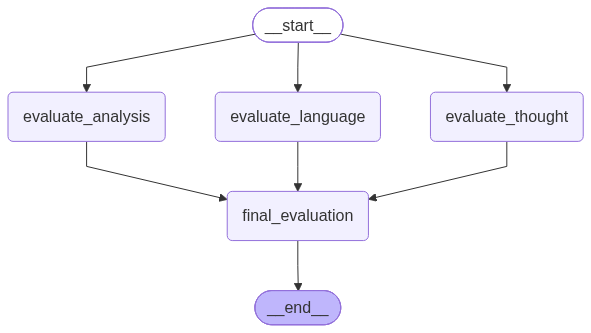

In [41]:
workflow

In [51]:
essay = """Technology has transformed the way students learn and teachers teach. In the past, students mainly depended on textbooks and classroom lectures, but today they can access a huge amount of information through computers, smartphones, and the internet.

One major advantage of technology in education is accessibility. Students can watch educational videos, attend online classes, read digital books, and use interactive learning tools from almost anywhere. This can make learning more flexible and engaging.

However, technology also has disadvantages. Excessive use of devices can distract students and reduce face-to-face interaction. Students may also become too dependent on the internet instead of developing their own problem-solving skills.

In conclusion, technology can greatly improve education when it is used properly. It should not replace teachers or traditional learning completely, but it should be used as a tool to make education more accessible, interactive, and effective.
"""

In [52]:
initial_state = {
    'essay' : essay
}

In [53]:
result = workflow.invoke(initial_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 54.094153974s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT